## abundance of phytoplankton

In [1]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath
from pathlib import Path


import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr

from cmocean import cm

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cmocean.cm as cm
import xarray as xr
from matplotlib.colors import LogNorm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


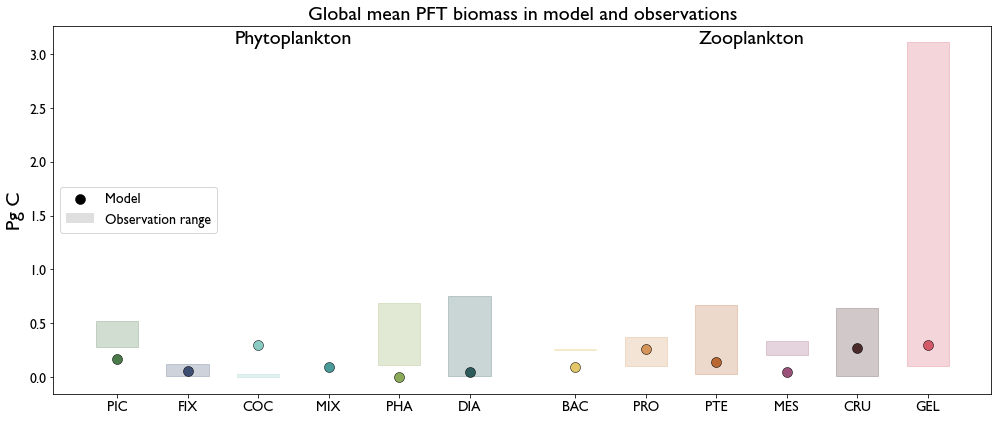

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

df = pd.read_csv('./data/phyto.csv')
df = df.dropna(subset=['species'])

# ============ EDITABLE PARAMETERS ============
label_fontsize = 20
tick_fontsize = 14
title_fontsize = 20
phyto_gap = 0.5  # extra space between phyto and zoo

phyto_species = ['PIC', 'FIX', 'COC', 'MIX', 'PHA', 'DIA']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'CRU', 'GEL']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}
# ============================================

# Reorder df to match phyto then zoo
order = phyto_species + zoo_species
df = df.set_index('species').loc[order].reset_index()

# Parse observation ranges
obs_low = []
obs_high = []
for val in df['observations']:
    val = str(val).strip()
    if '-' in val and val != 'NaN':
        parts = val.split('-')
        obs_low.append(float(parts[0].strip()))
        obs_high.append(float(parts[1].strip()))
    else:
        obs_low.append(np.nan)
        obs_high.append(np.nan)
df['obs_low'] = obs_low
df['obs_high'] = obs_high

# X positions with gap between phyto and zoo
n_phyto = len(phyto_species)
x = np.arange(len(df), dtype=float)
x[n_phyto:] += phyto_gap

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.6

# Plot observation range as faded rectangles with species color
for i, (_, row) in enumerate(df.iterrows()):
    color = species_colors.get(row['species'], 'grey')
    if not np.isnan(row['obs_low']):
        ax.fill_between([x[i] - bar_width/2, x[i] + bar_width/2],
                        row['obs_low'], row['obs_high'],
                        color=color, alpha=0.25)

# Plot model as colored points
for i, (_, row) in enumerate(df.iterrows()):
    color = species_colors.get(row['species'], 'grey')
    ax.scatter(x[i], row['model'], color=color, zorder=5, s=100,
               edgecolors='black', linewidths=0.5)

# Legend
obs_patch = Patch(facecolor='grey', alpha=0.25, label='Observation range')
ax.scatter([], [], color='black', s=100, edgecolors='black', linewidths=0.5, label='Model')
ax.legend(handles=[ax.collections[-1], obs_patch], fontsize=tick_fontsize, loc='center left')

ax.set_xticks(x)
ax.set_xticklabels(df['species'], fontsize=tick_fontsize, fontweight='bold')
ax.set_ylabel('Pg C', fontsize=label_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)
ax.set_title('Global mean PFT biomass in model and observations', fontsize=title_fontsize)

# Group labels
ax.text(np.mean(x[:n_phyto]), ax.get_ylim()[1] * 0.95, 'Phytoplankton',
        ha='center', fontsize=label_fontsize, fontstyle='italic')
ax.text(np.mean(x[n_phyto:]), ax.get_ylim()[1] * 0.95, 'Zooplankton',
        ha='center', fontsize=label_fontsize, fontstyle='italic')

plt.tight_layout()
fig.savefig('./plts/POSTER/obs-abundance.jpg', dpi=300)
plt.show()

### shifts (from Fig-shift)

In [3]:
runs = ['TOM12_TJ_OBC1', 'TOM12_TJ_OBA1', 'TOM12_TJ_OBH1']
ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc') 
                                for run in runs]

vars_phy = [
 'DIA',
 'MIX',
 'COC',
 'PIC',
 'PHA',
 'FIX']
vars_zoo =  [
 'BAC',
 'PRO',
 'PTE',
 'MES',
 'GEL',
'CRU',] 

In [4]:
make = False
if make:
    
    import matplotlib.ticker as ticker

    # ============ EDITABLE PARAMETERS ============
    title_fontsize = 20
    label_fontsize = 20
    vmin_abs = 1e-6
    vmax_abs = 5e-4
    abs_max_diff = 1e-4
    cbar_aspect = 30
    hspace = 0.02
    wspace = 0.05
    # ============================================

    tvars = vars_phy

    # Preload into memory
    ds_hist_loaded = ds_hist[tvars].load()
    ds_hose_loaded = ds_hose[tvars].load()

    fig, axes = plt.subplots(6, 2, figsize=(10, 16),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    data_crs = ccrs.PlateCarree()
    land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                         edgecolor='none',
                                         facecolor='lightgrey')
    col_titles = ['Historical run', 'Historical run \u2013 Hosing run']

    for i, var in enumerate(tvars):
        data_hist = ds_hist_loaded[var].mean(dim='time')
        data_hose = ds_hose_loaded[var].mean(dim='time')
        diff_hose = data_hist - data_hose

        # Left column: absolute with log scale
        ax = axes[i, 0]
        im1 = data_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                                  cmap=cm.haline,
                                  norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                                  add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

        ax.text(-0.025, 0.5, var, transform=ax.transAxes,
                fontsize=label_fontsize, fontweight='bold',
                rotation=90, va='center', ha='center')

        # Right column: difference
        ax = axes[i, 1]
        im2 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                             cmap='RdBu_r',
                             vmin=-abs_max_diff, vmax=abs_max_diff,
                             add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

    plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.12)

    col1_center = 0.05 + (0.95 - 0.05) / 4
    col2_center = 0.05 + 3 * (0.95 - 0.05) / 4
    cbar_width = 0.35
    cbar_height = 0.012
    ty = 0.09

    cax1 = fig.add_axes([col1_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
    cbar1.set_label('Concentration (mol m$^{-2}$)', fontsize=label_fontsize - 4)
    cbar1.ax.tick_params(labelsize=label_fontsize - 6)

    cax2 = fig.add_axes([col2_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
    cbar2.set_label('Difference (mol m$^{-2}$)', fontsize=label_fontsize - 4)
    cbar2.ax.tick_params(labelsize=label_fontsize - 6)
    cbar2.ax.ticklabel_format(style='sci', scilimits=(-4, -4), useMathText=True)
    cbar2.update_ticks()

    plt.savefig('./plts/POSTER/POSTER-Fig_phyto_shift.jpg', dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
make = False
if make:
    import matplotlib.ticker as ticker

    # ============ EDITABLE PARAMETERS ============
    title_fontsize = 20
    label_fontsize = 20
    vmin_abs = 1e-6
    vmax_abs = 5e-4
    abs_max_diff = 1e-4
    cbar_aspect = 30
    hspace = 0.02
    wspace = 0.05
    # ============================================

    tvars = vars_zoo

    # Preload into memory
    ds_hist_loaded = ds_hist[tvars].load()
    ds_hose_loaded = ds_hose[tvars].load()

    fig, axes = plt.subplots(6, 2, figsize=(10, 16),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    data_crs = ccrs.PlateCarree()
    land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                         edgecolor='none',
                                         facecolor='lightgrey')
    col_titles = ['Historical run', 'Historical run \u2013 Hosing run']

    for i, var in enumerate(tvars):
        data_hist = ds_hist_loaded[var].mean(dim='time')
        data_hose = ds_hose_loaded[var].mean(dim='time')
        diff_hose = data_hist - data_hose

        # Left column: absolute with log scale
        ax = axes[i, 0]
        im1 = data_hist.plot.pcolormesh(ax=ax, transform=data_crs,
                                  cmap=cm.matter,
                                  norm=LogNorm(vmin=vmin_abs, vmax=vmax_abs),
                                  add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[0], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

        ax.text(-0.025, 0.5, var, transform=ax.transAxes,
                fontsize=label_fontsize, fontweight='bold',
                rotation=90, va='center', ha='center')

        # Right column: difference
        ax = axes[i, 1]
        im2 = diff_hose.plot.pcolormesh(ax=ax, transform=data_crs,
                             cmap='RdBu_r',
                             vmin=-abs_max_diff, vmax=abs_max_diff,
                             add_colorbar=False)
        ax.add_feature(land, zorder=2)
        ax.coastlines()
        ax.set_global()
        if i == 0:
            ax.set_title(col_titles[1], fontsize=title_fontsize, fontweight='bold')
        else:
            ax.set_title('')

    plt.subplots_adjust(hspace=hspace, wspace=wspace, left=0.05, right=0.95, top=0.98, bottom=0.12)

    col1_center = 0.05 + (0.95 - 0.05) / 4
    col2_center = 0.05 + 3 * (0.95 - 0.05) / 4
    cbar_width = 0.35
    cbar_height = 0.012
    ty = 0.09

    cax1 = fig.add_axes([col1_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
    cbar1.set_label('Concentration (mol m$^{-2}$)', fontsize=label_fontsize - 4)
    cbar1.ax.tick_params(labelsize=label_fontsize - 6)

    cax2 = fig.add_axes([col2_center - cbar_width/2, ty, cbar_width, cbar_height])
    cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
    cbar2.set_label('Difference (mol m$^{-2}$)', fontsize=label_fontsize - 4)
    cbar2.ax.tick_params(labelsize=label_fontsize - 6)
    cbar2.ax.ticklabel_format(style='sci', scilimits=(-4, -4), useMathText=True)
    cbar2.update_ticks()

    plt.savefig('./plts/POSTER/POSTER-Fig_zoo_shift.jpg', dpi=300, bbox_inches='tight')
    plt.show()

## get provincial means for different species

In [6]:
ex = False
if ex:
    import xarray as xr
    import pandas as pd
    from pathlib import Path
    import numpy as np

    # Define runs
    runs = ['TOM12_TJ_OBA1', 'TOM12_TJ_OBC1', 'TOM12_TJ_OBH1']

    # Load datasets
    ds_cclim, ds_hist, ds_hose = [xr.open_dataset(f'/gpfs/data/greenocean/users/mep22dku/clims/{run}/ORCA2_1m_clim_2010_2019_ptrc_T_int.nc') 
                                    for run in runs]

    datasets = {'CCLIM': ds_cclim, 'HIST': ds_hist, 'HOSE': ds_hose}

    # Load masks
    MA = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/mask_atl.nc')
    mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

    # Define provinces (these are the weights!)
    provinces = {
        'GO': mask.csize,
        'AB': mask.csize * MA.AB,
        'HA': mask.csize * MA.HA,
        'NA': mask.csize * MA.NA
    }

    # Define variables
    vars_phy = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
    vars_zoo = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

    # Create output directory
    output_dir = Path('./data')
    output_dir.mkdir(exist_ok=True)

    # Function to calculate province means with proper weighting
    def calculate_province_means(ds, variables, provinces):
        """
        Calculate weighted spatial means over provinces for given variables.

        The province masks contain weights (cell sizes), so we compute:
        weighted_mean = sum(data * weights) / sum(weights)

        Parameters
        ----------
        ds : xr.Dataset
            Input dataset with variables
        variables : list of str
            List of variable names to process
        provinces : dict
            Dictionary of province_name: weight_mask pairs

        Returns
        -------
        pd.DataFrame
            DataFrame with columns: variable, province, value
        """
        results = []

        # Average over time dimension first
        ds_mean = ds.mean(dim='time')

        for var in variables:
            if var not in ds_mean:
                print(f"Warning: {var} not found in dataset")
                continue

            var_data = ds_mean[var]

            for prov_name, prov_mask in provinces.items():
                # Mask the data to the province (set values outside province to 0)
                masked_data = var_data.where(prov_mask > 0, 0)

                # Mask the weights to the province (set weights outside province to 0)
                masked_weights = prov_mask.where(prov_mask > 0, 0)

                # Get spatial dimensions (everything except time)
                spatial_dims = [d for d in masked_data.dims if d not in ['time_counter', 'time']]

                # Calculate weighted mean: sum(data * weights) / sum(weights)
                weighted_sum = (masked_data * masked_weights).sum(dim=spatial_dims)
                total_weight = masked_weights.sum(dim=spatial_dims)

                # Avoid division by zero
                if total_weight > 0:
                    prov_mean = float((weighted_sum / total_weight).values)
                else:
                    prov_mean = float('nan')

                results.append({
                    'variable': var,
                    'province': prov_name,
                    'value': prov_mean
                })

        return pd.DataFrame(results)


    # Process all datasets and store results
    all_results = {}

    for dataset_name, ds in datasets.items():
        print(f"\n{'='*60}")
        print(f"Processing {dataset_name}...")
        print(f"{'='*60}")

        # Calculate for phytoplankton
        df_phy = calculate_province_means(ds, vars_phy, provinces)
        df_phy['model'] = dataset_name
        all_results[f'{dataset_name}_phytoplankton'] = df_phy

        output_file = output_dir / f'{dataset_name}_phytoplankton_province_means.csv'
        df_phy.to_csv(output_file, index=False)
        print(f"Saved phytoplankton: {output_file}")
        #print(df_phy)

        # Calculate for zooplankton
        df_zoo = calculate_province_means(ds, vars_zoo, provinces)
        df_zoo['model'] = dataset_name
        all_results[f'{dataset_name}_zooplankton'] = df_zoo

        output_file = output_dir / f'{dataset_name}_zooplankton_province_means.csv'
        df_zoo.to_csv(output_file, index=False)
        print(f"Saved zooplankton: {output_file}")
        #print(df_zoo)

    print(f"\n{'='*60}")
    print("All datasets processed!")
    print(f"{'='*60}")

    # Combine all results
    df_all = pd.concat(all_results.values(), ignore_index=True)
    df_all.to_csv(output_dir / 'TESTall_province_means.csv', index=False)
    print(f"Combined results saved to: {output_dir / 'all_province_means.csv'}")


## bar graphs of changes in zooplankton

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


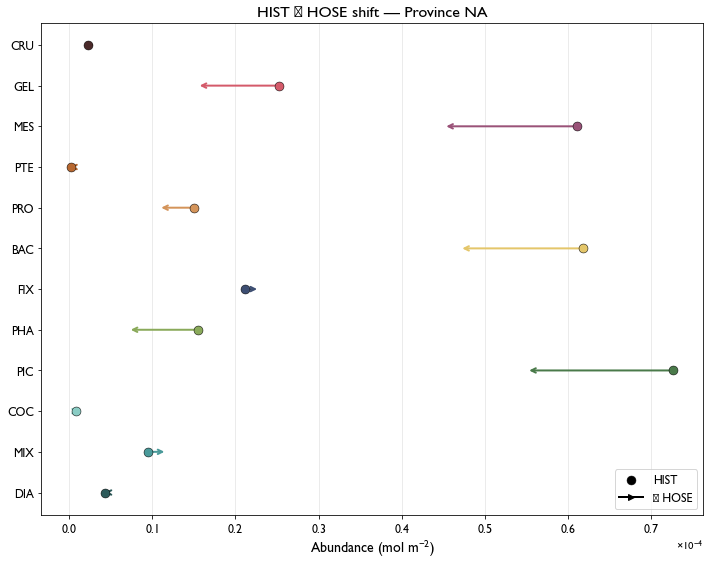

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
province = 'NA'
label_fontsize = 14
tick_fontsize = 12
title_fontsize = 16
arrow_linewidth = 2
dot_size = 80

krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}
# ============================================

prov = df[df['province'] == province]
hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
common = hist.index.intersection(hose.index)
hist = hist.loc[common]
hose = hose.loc[common]

species = hist.index.tolist()
y = np.arange(len(species))

fig, ax = plt.subplots(figsize=(10, 8))

for i, sp in enumerate(species):
    color = species_colors.get(sp, 'grey')
    h = hist[sp]
    ho = hose[sp]
    # Arrow from HIST to HOSE
    ax.annotate('', xy=(ho, i), xytext=(h, i),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=arrow_linewidth))
    # Dot at HIST
    ax.scatter(h, i, color=color, s=dot_size, zorder=5, edgecolors='black', linewidths=0.5)

ax.set_yticks(y)
ax.set_yticklabels(species, fontsize=tick_fontsize)
ax.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)
ax.set_title(f'HIST → HOSE shift — Province {province}', fontsize=title_fontsize)
ax.tick_params(axis='x', labelsize=tick_fontsize)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-4, -4), useMathText=True)

# Legend
ax.scatter([], [], color='black', s=dot_size, edgecolors='black', linewidths=0.5, label='HIST')
ax.annotate('', xy=(0, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=arrow_linewidth))
ax.plot([], [], color='black', marker='>', linestyle='-', lw=arrow_linewidth, label='→ HOSE')
ax.legend(fontsize=tick_fontsize, loc='lower right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## butterfly plot

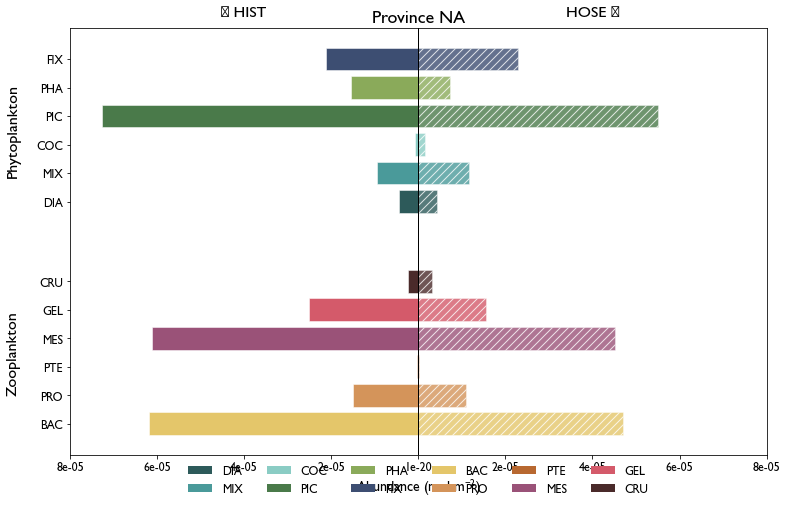

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
province = 'NA'
label_fontsize = 14
tick_fontsize = 12
title_fontsize = 16
bar_height = 0.4
bar_spacing = 0.5
gap = 1.4
xmax = 8e-5

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}
# ============================================

prov = df[df['province'] == province]
hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
common = hist.index.intersection(hose.index)
hist = hist.loc[common]
hose = hose.loc[common]

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)
y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])
colors = [species_colors[s] for s in all_species]

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(y_all, -hist[all_species].values, height=bar_height,
        color=colors, edgecolor='white', linewidth=0.5, align='center')

ax.barh(y_all, hose[all_species].values, height=bar_height,
        color=colors, edgecolor='white', linewidth=0.5, align='center',
        hatch='///', alpha=0.8)

ax.axvline(0, color='black', linewidth=1)

ax.set_yticks(y_all)
ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')

# Fixed x axis with ticks every 2e-5
ax.set_xlim(-xmax, xmax)
ticks = np.arange(-8e-5, 8.01e-5, 2e-5)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{abs(t):.0e}' for t in ticks], fontsize=tick_fontsize)

ax.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)
ax.set_title(f'Province {province}', fontsize=title_fontsize + 2, fontweight='bold')

ax.text(-xmax * 0.5, y_all.max() + 0.8, '← HIST', fontsize=title_fontsize,
        fontweight='bold', ha='center', va='center')
ax.text(xmax * 0.5, y_all.max() + 0.8, 'HOSE →', fontsize=title_fontsize,
        fontweight='bold', ha='center', va='center')

# Group labels outside plot area
ylim = ax.get_ylim()
ax.text(-0.08, (np.mean(y_phyto) - ylim[0]) / (ylim[1] - ylim[0]),
        'Phytoplankton', fontsize=title_fontsize, fontweight='bold',
        rotation=90, va='center', ha='center', transform=ax.transAxes)
ax.text(-0.08, (np.mean(y_zoo) - ylim[0]) / (ylim[1] - ylim[0]),
        'Zooplankton', fontsize=title_fontsize, fontweight='bold',
        rotation=90, va='center', ha='center', transform=ax.transAxes)

# Legend in 2 rows
legend_patches = [mpatches.Patch(facecolor=species_colors[s], label=s) for s in all_species]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), ncol=6,
          fontsize=tick_fontsize, frameon=False)

plt.tight_layout(rect=[0.08, 0.05, 1, 0.95])
plt.show()

## four-series butterfly plot

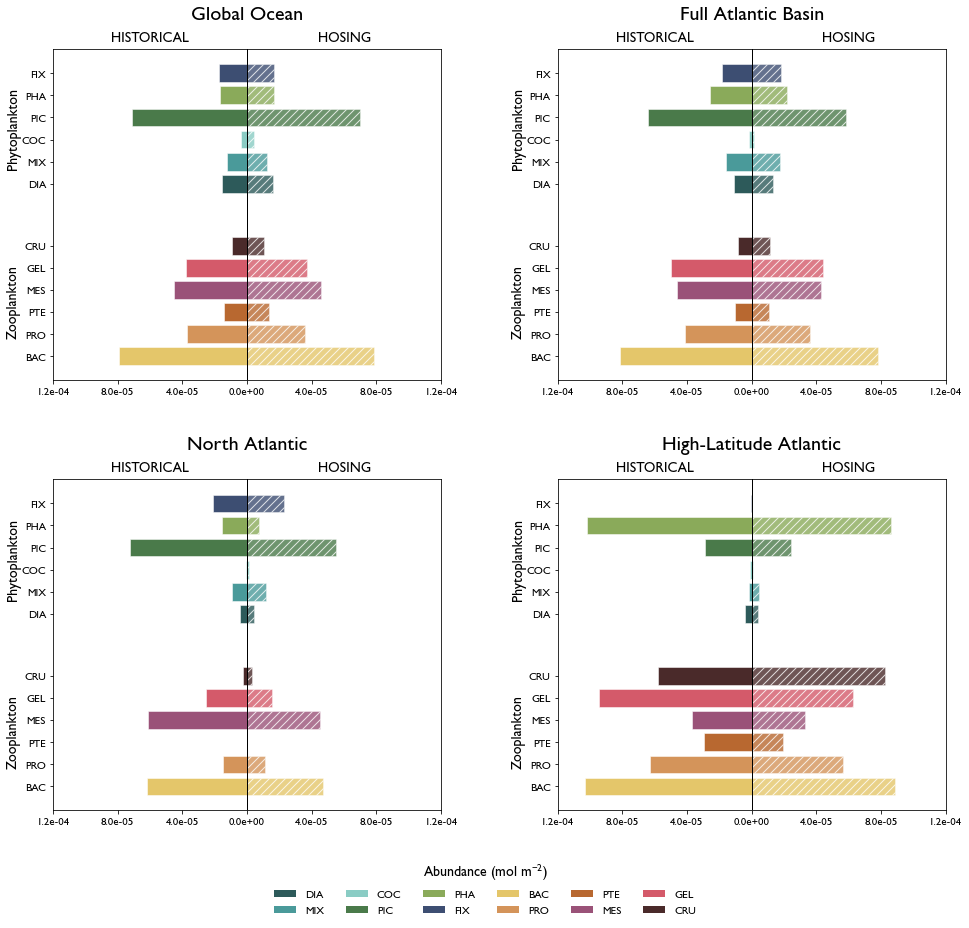

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 14
tick_fontsize = 11
title_fontsize = 16
bar_height = 0.4
bar_spacing = 0.5
gap = 1.4
xmax = 1.2e-4
ticks = np.array([-12, -8, -4, 0, 4, 8, 12]) * 1e-5

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude Atlantic',
}

provinces = ['GO', 'AB', 'NA', 'HA']
# ============================================

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)
y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])
colors = [species_colors[s] for s in all_species]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         gridspec_kw={'hspace': 0.3, 'wspace': 0.3})

for idx, province in enumerate(provinces):
    ax = axes[idx // 2, idx % 2]

    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
    common = hist.index.intersection(hose.index)
    hist = hist.loc[common]
    hose = hose.loc[common]

    ax.barh(y_all, -hist[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center')
    ax.barh(y_all, hose[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center',
            hatch='///', alpha=0.8)

    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y_all)
    ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')

    ax.set_xlim(-xmax, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{abs(t):.1e}' for t in ticks], fontsize=tick_fontsize)

    ax.set_title(province_names[province], fontsize=title_fontsize + 4,
                 fontweight='bold', pad=30)

    ax.text(-xmax * 0.5, y_all.max() + 0.8, 'HISTORICAL', fontsize=title_fontsize - 2,
            fontweight='bold', ha='center', va='center')
    ax.text(xmax * 0.5, y_all.max() + 0.8, 'HOSING', fontsize=title_fontsize - 2,
            fontweight='bold', ha='center', va='center')

    # Group labels outside plot
    ylim = ax.get_ylim()
    ax.text(-0.1, (np.mean(y_phyto) - ylim[0]) / (ylim[1] - ylim[0]),
            'Phytoplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)
    ax.text(-0.1, (np.mean(y_zoo) - ylim[0]) / (ylim[1] - ylim[0]),
            'Zooplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)

# Shared x label
fig.text(0.5, 0.06, 'Abundance (mol m$^{-2}$)', ha='center', fontsize=label_fontsize)

# Legend at very bottom, below x label
legend_patches = [mpatches.Patch(facecolor=species_colors[s], label=s) for s in all_species]
fig.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, 0.01), ncol=6,
           fontsize=tick_fontsize, frameon=False)

plt.tight_layout(rect=[0.06, 0.08, 1, 0.97])
fig.savefig('./plts/POSTER/butterfly.jpg', dpi = 300)
plt.show()

## second attempt?

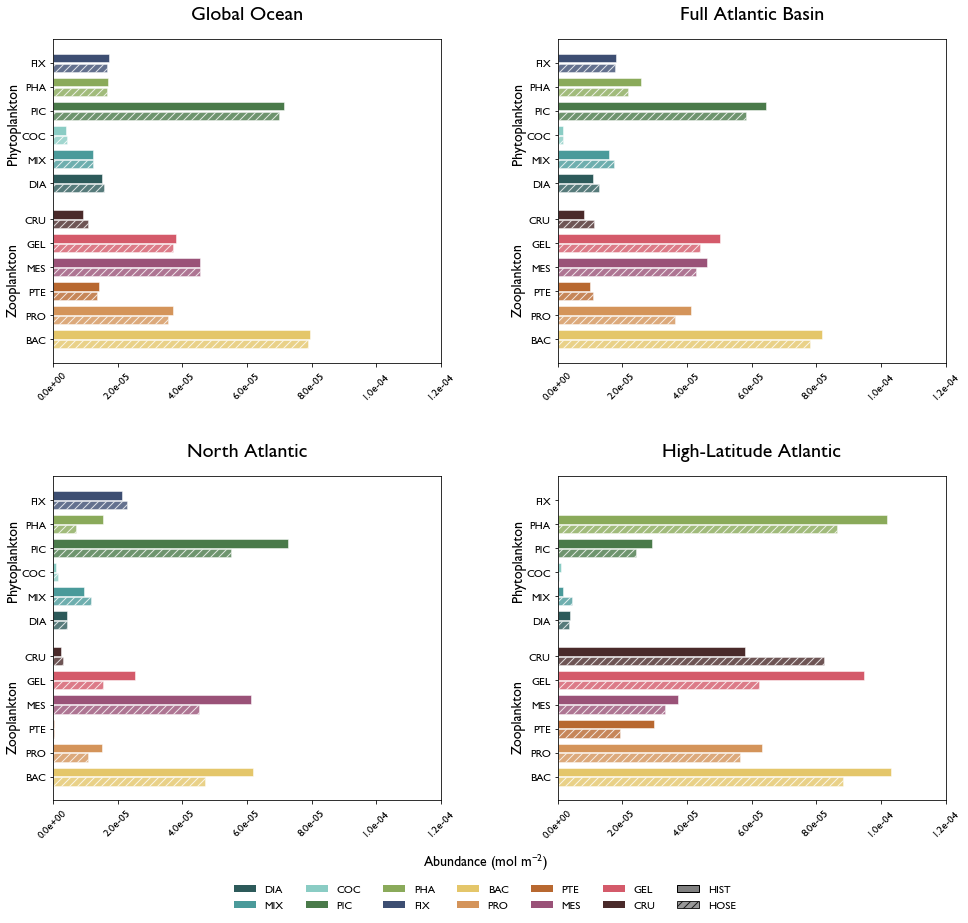

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 14
tick_fontsize = 11
title_fontsize = 16
bar_height = 0.35
bar_offset = 0.2  # offset between HIST and HOSE bars
bar_spacing = 1.0  # distance between species centres
gap = 1.5  # gap between phyto and zoo groups
xmax = 1.2e-4
ticks = np.array([0, 2, 4, 6, 8, 10, 12]) * 1e-5

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude Atlantic',
}

provinces = ['GO', 'AB', 'NA', 'HA']
# ============================================

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)

y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])

colors = [species_colors[s] for s in all_species]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         gridspec_kw={'hspace': 0.35, 'wspace': 0.3})

for idx, province in enumerate(provinces):
    ax = axes[idx // 2, idx % 2]

    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
    common = hist.index.intersection(hose.index)
    hist = hist.loc[common]
    hose = hose.loc[common]

    # HIST bars (top of pair)
    ax.barh(y_all + bar_offset, hist[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center')

    # HOSE bars (bottom of pair, hatched)
    ax.barh(y_all - bar_offset, hose[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center',
            hatch='///', alpha=0.8)

    ax.set_yticks(y_all)
    ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')

    ax.set_xlim(0, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:.1e}' for t in ticks], fontsize=tick_fontsize)
    ax.tick_params(axis='x', rotation=45)

    ax.set_title(province_names[province], fontsize=title_fontsize + 4,
                 fontweight='bold', pad=20)

    # Group labels outside plot
    ylim = ax.get_ylim()
    ax.text(-0.1, (np.mean(y_phyto) - ylim[0]) / (ylim[1] - ylim[0]),
            'Phytoplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)
    ax.text(-0.1, (np.mean(y_zoo) - ylim[0]) / (ylim[1] - ylim[0]),
            'Zooplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)

# Shared x label
fig.text(0.5, 0.06, 'Abundance (mol m$^{-2}$)', ha='center', fontsize=label_fontsize)

# Legend: species colors + HIST/HOSE distinction
legend_patches = [mpatches.Patch(facecolor=species_colors[s], label=s) for s in all_species]
hist_patch = mpatches.Patch(facecolor='grey', edgecolor='black', label='HIST')
hose_patch = mpatches.Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.8, label='HOSE')
all_handles = legend_patches + [hist_patch, hose_patch]

fig.legend(handles=all_handles, loc='lower center',
           bbox_to_anchor=(0.5, 0.005), ncol=7,
           fontsize=tick_fontsize, frameon=False)

plt.tight_layout(rect=[0.06, 0.08, 1, 0.97])
fig.savefig('./plts/POSTER/paired_bars.jpg', dpi=300)
plt.show()

## single-column, with total sum at bottom

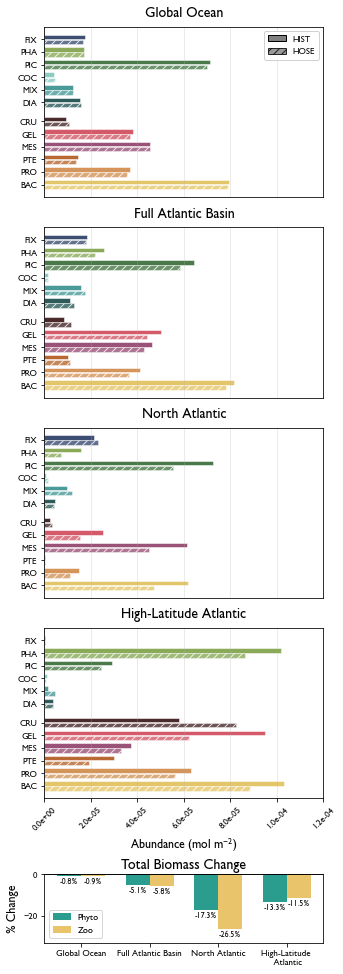

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 12
tick_fontsize = 9
title_fontsize = 14
bar_height = 0.35
bar_offset = 0.2
bar_spacing = 1.0
gap = 1.5
xmax = 1.2e-4
ticks = np.array([0, 2, 4, 6, 8, 10, 12]) * 1e-5
phyto_color = '#2a9d8f'
zoo_color = '#e9c46a'

## PLAY WITH THESE to control spacing
top_hspace = 0.2        # vertical spacing between the top 4 plots (smaller = tighter)
bottom_nudge = 0.04     # how far to push the bottom plot down (bigger = more gap)

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude Atlantic',
}

provinces = ['GO', 'AB', 'NA', 'HA']
# ============================================

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)

y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])
colors = [species_colors[s] for s in all_species]

fig = plt.figure(figsize=(5, 16))
gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 0.4],
                      hspace=top_hspace)

for idx, province in enumerate(provinces):
    ax = fig.add_subplot(gs[idx, 0])

    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
    common = hist.index.intersection(hose.index)
    hist = hist.loc[common]
    hose = hose.loc[common]

    ax.barh(y_all + bar_offset, hist[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center')
    ax.barh(y_all - bar_offset, hose[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center',
            hatch='///', alpha=0.8)

    ax.set_yticks(y_all)
    ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')
    ax.set_xlim(0, xmax)
    ax.set_xticks(ticks)
    ax.grid(axis='x', alpha=0.3)
    ax.set_title(province_names[province], fontsize=title_fontsize,
                 fontweight='bold', pad=10)

    if idx < 3:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
    else:
        ax.set_xticklabels([f'{t:.1e}' for t in ticks], fontsize=tick_fontsize)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)

    if idx == 0:
        hist_patch = mpatches.Patch(facecolor='grey', edgecolor='black', label='HIST')
        hose_patch = mpatches.Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.8, label='HOSE')
        ax.legend(handles=[hist_patch, hose_patch], fontsize=tick_fontsize,
                  loc='upper right', framealpha=0.9)

# --- Bottom row: % change ---
ax_pct = fig.add_subplot(gs[4, 0])

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude \n Atlantic',
}


phyto_pct = []
zoo_pct = []
for province in provinces:
    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']

    hist_phyto = hist[phyto_species].sum()
    hose_phyto = hose[phyto_species].sum()
    phyto_pct.append((hose_phyto - hist_phyto) / hist_phyto * 100)

    hist_zoo = hist[zoo_species].sum()
    hose_zoo = hose[zoo_species].sum()
    zoo_pct.append((hose_zoo - hist_zoo) / hist_zoo * 100)

x = np.arange(len(provinces))
pct_bar_width = 0.35

ax_pct.bar(x - pct_bar_width/2, phyto_pct, pct_bar_width, color=phyto_color, label='Phyto')
ax_pct.bar(x + pct_bar_width/2, zoo_pct, pct_bar_width, color=zoo_color, label='Zoo')
ax_pct.axhline(0, color='black', linewidth=0.8)
ax_pct.set_xticks(x)
ax_pct.set_xticklabels([province_names[p] for p in provinces], fontsize=tick_fontsize-2, fontweight='bold')
ax_pct.set_ylabel('% Change', fontsize=label_fontsize)
ax_pct.set_title('Total Biomass Change', fontsize=title_fontsize, fontweight='bold')
ax_pct.tick_params(axis='both', labelsize=tick_fontsize)
ax_pct.legend(fontsize=tick_fontsize, loc='lower left')
#ax_pct.grid(axis='y', alpha=0.3)
ax_pct.set_ylim([-33,0])

for i in range(len(provinces)):
    ax_pct.text(x[i] - pct_bar_width/2, phyto_pct[i] + (0.5 if phyto_pct[i] >= 0 else -3.5),
                f'{phyto_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 1)
    ax_pct.text(x[i] + pct_bar_width/2, zoo_pct[i] + (0.5 if zoo_pct[i] >= 0 else -3.5),
                f'{zoo_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 1)

plt.tight_layout()

# Nudge bottom plot down to avoid overlapping the abundance label
pos = ax_pct.get_position()
ax_pct.set_position([pos.x0, pos.y0 - bottom_nudge, pos.width, pos.height])

fig.savefig('./plts/POSTER/paired_bars_column.jpg', dpi=300, bbox_inches='tight')
plt.show()

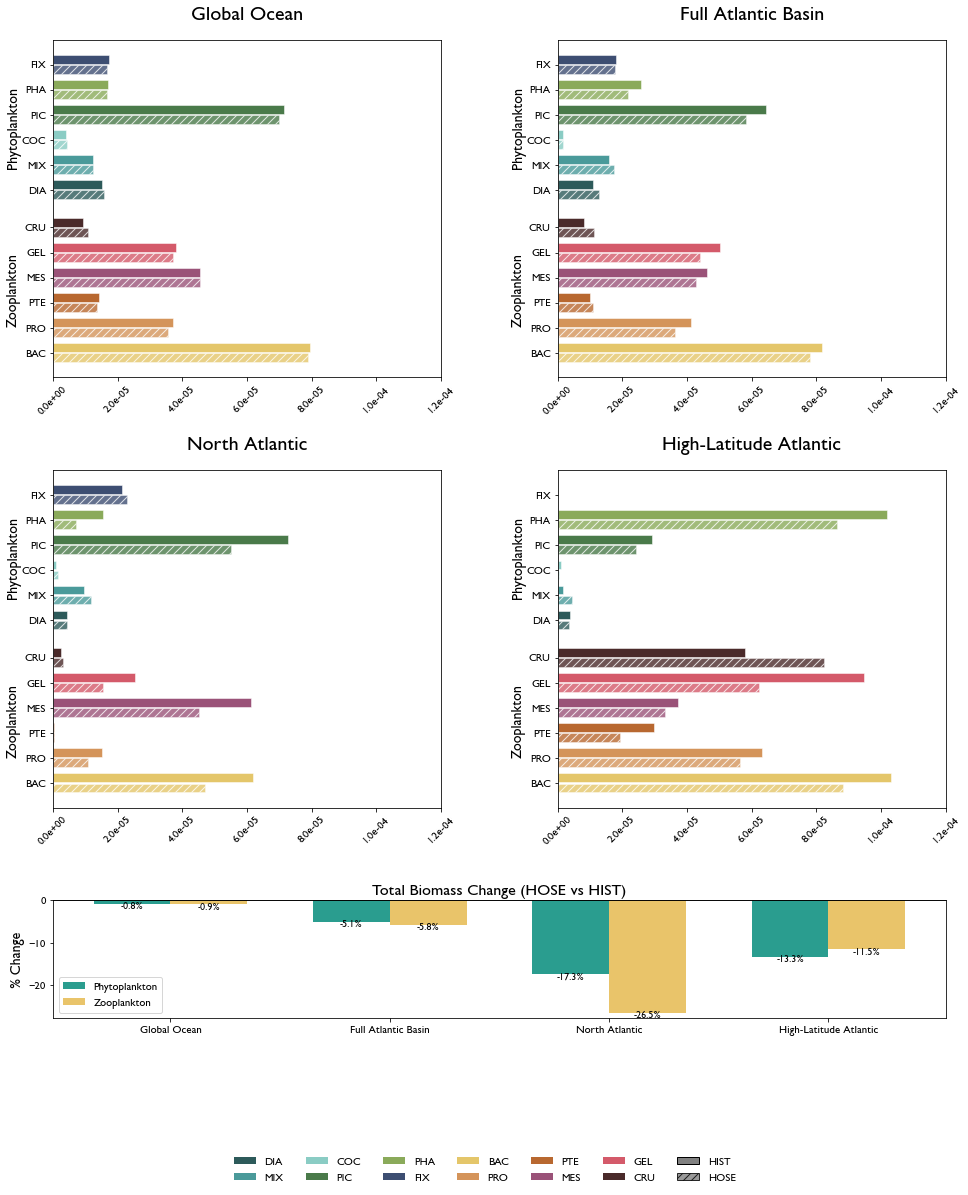

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('./data/TESTall_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 14
tick_fontsize = 11
title_fontsize = 16
bar_height = 0.35
bar_offset = 0.2
bar_spacing = 1.0
gap = 1.5
xmax = 1.2e-4
ticks = np.array([0, 2, 4, 6, 8, 10, 12]) * 1e-5
phyto_color = '#2a9d8f'
zoo_color = '#e9c46a'

phyto_species = ['DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX']
zoo_species = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'CRU']

species_colors = {
    'DIA': '#2d5a5a',
    'MIX': '#4a9a9a',
    'COC': '#8accc4',
    'PIC': '#4a7a4a',
    'PHA': '#8aaa5a',
    'FIX': '#3d4e72',
    'BAC': '#e4c66a',
    'PRO': '#d4945a',
    'PTE': '#b86830',
    'MES': '#9a5278',
    'GEL': '#d45a6a',
    'CRU': '#4a2a2a',
}

province_names = {
    'GO': 'Global Ocean',
    'AB': 'Full Atlantic Basin',
    'NA': 'North Atlantic',
    'HA': 'High-Latitude Atlantic',
}

provinces = ['GO', 'AB', 'NA', 'HA']
# ============================================

all_species = phyto_species + zoo_species
n_phyto = len(phyto_species)
n_zoo = len(zoo_species)

y_zoo = np.arange(n_zoo) * bar_spacing
y_phyto = np.arange(n_phyto) * bar_spacing + y_zoo[-1] + gap
y_all = np.concatenate([y_phyto, y_zoo])
colors = [species_colors[s] for s in all_species]

# Create figure with gridspec: 2 rows of paired bars + 1 skinny row for % change
fig = plt.figure(figsize=(16, 18))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.35],
                      hspace=0.35, wspace=0.3)

# --- Top 2x2: paired bar charts ---
for idx, province in enumerate(provinces):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])

    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
    common = hist.index.intersection(hose.index)
    hist = hist.loc[common]
    hose = hose.loc[common]

    ax.barh(y_all + bar_offset, hist[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center')
    ax.barh(y_all - bar_offset, hose[all_species].values, height=bar_height,
            color=colors, edgecolor='white', linewidth=0.5, align='center',
            hatch='///', alpha=0.8)

    ax.set_yticks(y_all)
    ax.set_yticklabels(all_species, fontsize=tick_fontsize, fontweight='bold')
    ax.set_xlim(0, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:.1e}' for t in ticks], fontsize=tick_fontsize)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(province_names[province], fontsize=title_fontsize + 4,
                 fontweight='bold', pad=20)

    ylim = ax.get_ylim()
    ax.text(-0.1, (np.mean(y_phyto) - ylim[0]) / (ylim[1] - ylim[0]),
            'Phytoplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)
    ax.text(-0.1, (np.mean(y_zoo) - ylim[0]) / (ylim[1] - ylim[0]),
            'Zooplankton', fontsize=label_fontsize, fontweight='bold',
            rotation=90, va='center', ha='center', transform=ax.transAxes)

# --- Bottom row: % change spanning both columns ---
ax_pct = fig.add_subplot(gs[2, :])

phyto_pct = []
zoo_pct = []
for province in provinces:
    prov = df[df['province'] == province]
    hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
    hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']

    hist_phyto = hist[phyto_species].sum()
    hose_phyto = hose[phyto_species].sum()
    phyto_pct.append((hose_phyto - hist_phyto) / hist_phyto * 100)

    hist_zoo = hist[zoo_species].sum()
    hose_zoo = hose[zoo_species].sum()
    zoo_pct.append((hose_zoo - hist_zoo) / hist_zoo * 100)

x = np.arange(len(provinces))
pct_bar_width = 0.35

ax_pct.bar(x - pct_bar_width/2, phyto_pct, pct_bar_width, color=phyto_color, label='Phytoplankton')
ax_pct.bar(x + pct_bar_width/2, zoo_pct, pct_bar_width, color=zoo_color, label='Zooplankton')
ax_pct.axhline(0, color='black', linewidth=0.8)
ax_pct.set_xticks(x)
ax_pct.set_xticklabels([province_names[p] for p in provinces], fontsize=tick_fontsize, fontweight='bold')
ax_pct.set_ylabel('% Change', fontsize=label_fontsize)
ax_pct.set_title('Total Biomass Change (HOSE vs HIST)', fontsize=title_fontsize, fontweight='bold')
ax_pct.tick_params(axis='y', labelsize=tick_fontsize)
ax_pct.legend(fontsize=tick_fontsize, loc='lower left')
#ax_pct.grid(axis='y', alpha=0.3)

for i in range(len(provinces)):
    ax_pct.text(x[i] - pct_bar_width/2, phyto_pct[i] + (0.5 if phyto_pct[i] >= 0 else -1.2),
                f'{phyto_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 1)
    ax_pct.text(x[i] + pct_bar_width/2, zoo_pct[i] + (0.5 if zoo_pct[i] >= 0 else -1.2),
                f'{zoo_pct[i]:.1f}%', ha='center', fontsize=tick_fontsize - 1)

# Legend for paired bars
legend_patches = [mpatches.Patch(facecolor=species_colors[s], label=s) for s in all_species]
hist_patch = mpatches.Patch(facecolor='grey', edgecolor='black', label='HIST')
hose_patch = mpatches.Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.8, label='HOSE')
all_handles = legend_patches + [hist_patch, hose_patch]

fig.legend(handles=all_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), ncol=7,
           fontsize=tick_fontsize, frameon=False)

plt.tight_layout(rect=[0.06, 0.03, 1, 0.97])
fig.savefig('./plts/POSTER/paired_bars_with_pct.jpg', dpi=300, bbox_inches='tight')
plt.show()

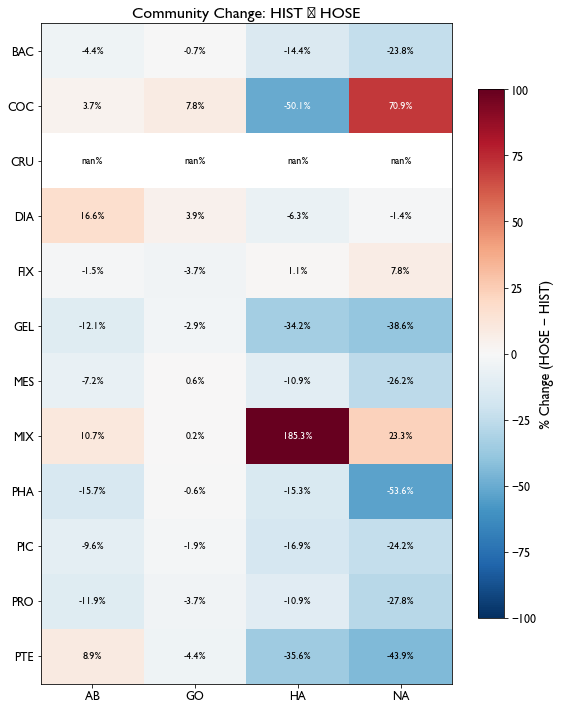

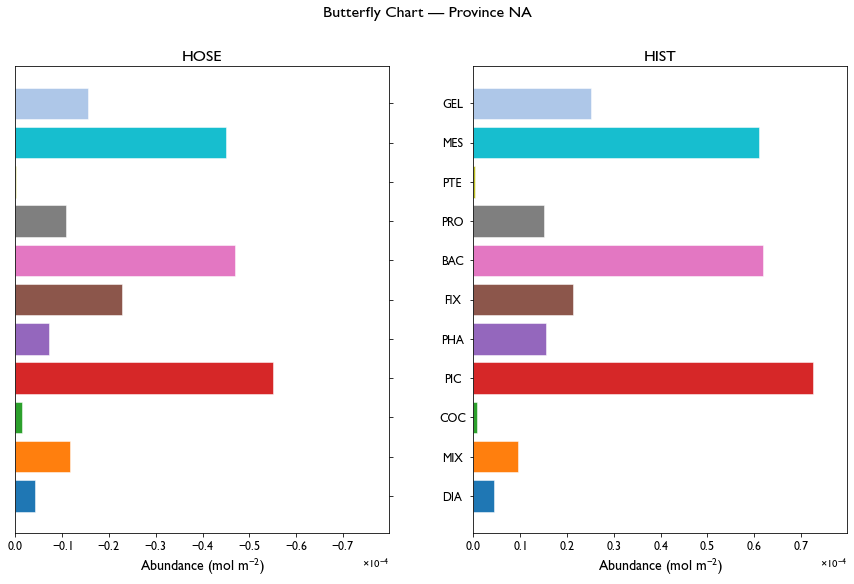

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv('./data/all_province_means.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['province'] = df['province'].fillna('NA')
df.columns = df.columns.str.strip()
df['variable'] = df['variable'].str.strip()
df['province'] = df['province'].str.strip()
df['model'] = df['model'].str.strip()

# ============ EDITABLE PARAMETERS ============
label_fontsize = 14
tick_fontsize = 12
title_fontsize = 16

species_colors = {
    'DIA': '#1f77b4',
    'MIX': '#ff7f0e',
    'COC': '#2ca02c',
    'PIC': '#d62728',
    'PHA': '#9467bd',
    'FIX': '#8c564b',
    'BAC': '#e377c2',
    'PRO': '#7f7f7f',
    'PTE': '#bcbd22',
    'MES': '#17becf',
    'GEL': '#aec7e8',
    'CRU': '#ffbb78',
}
# ============================================

# Pivot out HIST and HOSE
hist_all = df[df['model'] == 'HIST'].pivot(index='variable', columns='province', values='value')
hose_all = df[df['model'] == 'HOSE'].pivot(index='variable', columns='province', values='value')
pct_change = ((hose_all - hist_all) / hist_all) * 100

# ==========================================
# HEATMAP: % change across all provinces
# ==========================================
fig, ax = plt.subplots(figsize=(8, 10))

im = ax.imshow(pct_change.values, cmap='RdBu_r', aspect='auto',
               vmin=-100, vmax=100)

ax.set_xticks(np.arange(len(pct_change.columns)))
ax.set_xticklabels(pct_change.columns, fontsize=tick_fontsize)
ax.set_yticks(np.arange(len(pct_change.index)))
ax.set_yticklabels(pct_change.index, fontsize=tick_fontsize)

# Annotate cells with values
for i in range(len(pct_change.index)):
    for j in range(len(pct_change.columns)):
        val = pct_change.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=tick_fontsize - 2,
                color='white' if abs(val) > 50 else 'black')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% Change (HOSE − HIST)', fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)
ax.set_title('Community Change: HIST → HOSE', fontsize=title_fontsize)
plt.tight_layout()
plt.show()


# ==========================================
# BUTTERFLY CHART for a single province
# ==========================================
province = 'NA'

prov = df[df['province'] == province]
hist = prov[prov['model'] == 'HIST'].set_index('variable')['value']
hose = prov[prov['model'] == 'HOSE'].set_index('variable')['value']
common = hist.index.intersection(hose.index)
hist = hist.loc[common]
hose = hose.loc[common]
species = hist.index.tolist()
y = np.arange(len(species))
colors = [species_colors.get(s, 'grey') for s in species]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

# Left side: HOSE (bars going left)
ax_left.barh(y, -hose.values, color=colors, edgecolor='white', linewidth=0.5)
ax_left.set_xlim(-hist.max() * 1.1, 0)
ax_left.invert_xaxis()
ax_left.set_title('HOSE', fontsize=title_fontsize, loc='center')
ax_left.tick_params(axis='both', labelsize=tick_fontsize)
ax_left.ticklabel_format(axis='x', style='sci', scilimits=(-4, -4), useMathText=True)
ax_left.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)

# Right side: HIST (bars going right)
ax_right.barh(y, hist.values, color=colors, edgecolor='white', linewidth=0.5)
ax_right.set_xlim(0, hist.max() * 1.1)
ax_right.set_title('HIST', fontsize=title_fontsize, loc='center')
ax_right.tick_params(axis='both', labelsize=tick_fontsize)
ax_right.ticklabel_format(axis='x', style='sci', scilimits=(-4, -4), useMathText=True)
ax_right.set_xlabel('Abundance (mol m$^{-2}$)', fontsize=label_fontsize)

# Species labels in the middle
ax_left.set_yticks(y)
ax_left.set_yticklabels(species, fontsize=tick_fontsize, ha='center')
ax_left.yaxis.set_ticks_position('right')
# Shift labels to sit between the two axes
for label in ax_left.get_yticklabels():
    label.set_position((1.15, 0))

fig.suptitle(f'Butterfly Chart — Province {province}', fontsize=title_fontsize, y=1.01)
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()